# Prepare Dataset
Input:
- Directory containing HLW camera trap MP4 videos for each location (e.g., H03, H23)
- COCO annotations with frame-video mapping filenames

Output:
- Stratified Train/val/test split.json

In [2]:
import os
import sys
import json
import copy
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import supervision as sv

sys.path.insert(0, str(Path("..").resolve()))
from hlwdetector.visualization.video_annotator import VideoAnnotator

sys.path.insert(0, str(Path("../utilities").resolve()))
from video_dataset_prep_tools import compute_split_statistics, stratified_video_split, split_report, extract_frames_from_dir, remove_multi_bird_frames
from annotation_converter import AnnotationConverter

In [3]:
sites = ["h03", "h23"]
video_dirs = {}
video_arrs = {}
coco_ann_files = {}
for site in sites:
    video_dirs[site] = Path(f"../data/{site}/videos")
    #video_arrs[site] = [f for f in os.listdir(video_dirs[site]) if f.lower().endswith('.mp4')]
    coco_ann_files[site] = Path(f"../data/{site}/instances_merged.json")

## Prepare Images

### Extract Frames

In [3]:
#for site in sites:
#    out_dir = Path(f"../data/{site}/images")
#    extract_frames_from_dir(video_dirs[site], out_dir)

### Sanity Check: Annotations vs. Extracted Frames

For each site, sample 3 frames with bird detections and plot ground truth bounding boxes. This verifies that frame filenames in the COCO annotations match the extracted frames on disk.

SupervisionWarnings: BoundingBoxAnnotator is deprecated: `BoundingBoxAnnotator` is deprecated and has been renamed to `BoxAnnotator`. `BoundingBoxAnnotator` will be removed in supervision-0.26.0.
SupervisionWarnings: BoundingBoxAnnotator is deprecated: `BoundingBoxAnnotator` is deprecated and has been renamed to `BoxAnnotator`. `BoundingBoxAnnotator` will be removed in supervision-0.26.0.
SupervisionWarnings: BoundingBoxAnnotator is deprecated: `BoundingBoxAnnotator` is deprecated and has been renamed to `BoxAnnotator`. `BoundingBoxAnnotator` will be removed in supervision-0.26.0.
SupervisionWarnings: BoundingBoxAnnotator is deprecated: `BoundingBoxAnnotator` is deprecated and has been renamed to `BoxAnnotator`. `BoundingBoxAnnotator` will be removed in supervision-0.26.0.


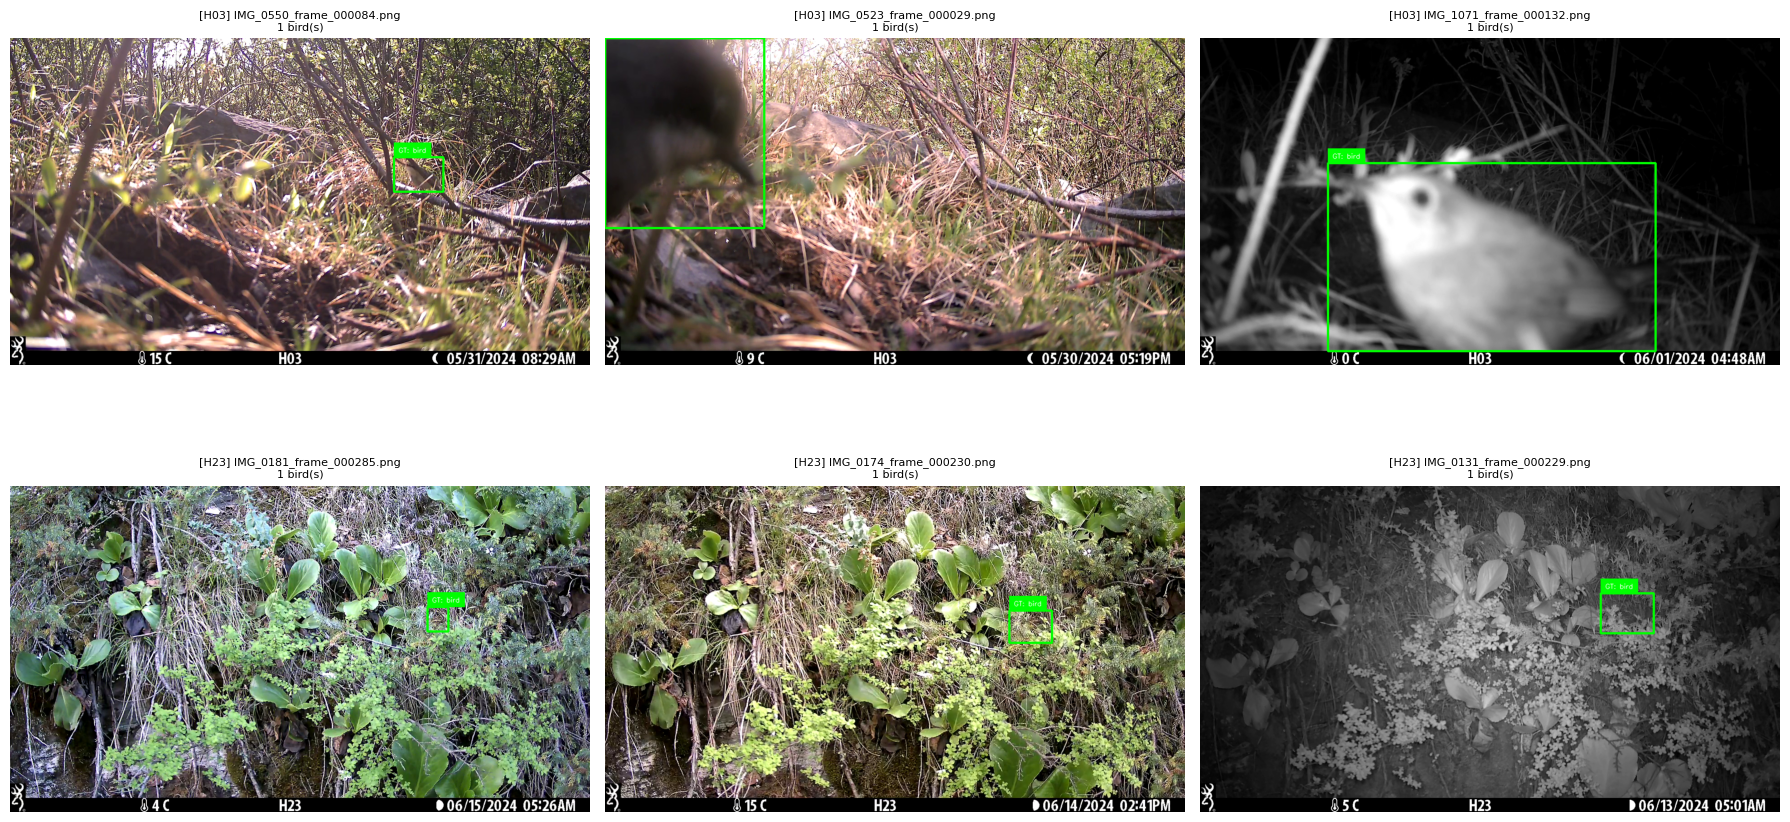

✓ All sampled frames found on disk


In [4]:
N_SAMPLES = 3
random.seed(42)

n_sites = len(sites)
fig, axes = plt.subplots(n_sites, N_SAMPLES, figsize=(N_SAMPLES * 6, n_sites * 5))
if n_sites == 1:
    axes = [axes]

all_ok = True

for row_idx, site in enumerate(sites):
    with open(coco_ann_files[site]) as f:
        coco = json.load(f)

    # Build stem -> sv.Detections from COCO [x,y,w,h] annotations
    id_to_stem = {img["id"]: Path(img["file_name"]).stem for img in coco["images"]}
    stem_to_boxes: dict[str, list] = {}
    for ann in coco["annotations"]:
        stem = id_to_stem.get(ann["image_id"])
        if stem is None:
            continue
        x, y, w, h = ann["bbox"]
        stem_to_boxes.setdefault(stem, []).append([x, y, x + w, y + h])
    gt_detections = {
        stem: sv.Detections(
            xyxy=np.array(boxes, dtype=np.float32),
            class_id=np.zeros(len(boxes), dtype=int),
        )
        for stem, boxes in stem_to_boxes.items()
    }

    # Sample 3 annotated frames
    annotated_ids = {ann["image_id"] for ann in coco["annotations"]}
    imgs_with_birds = [img for img in coco["images"] if img["id"] in annotated_ids]
    sampled = random.sample(imgs_with_birds, min(N_SAMPLES, len(imgs_with_birds)))

    images_dir = Path(f"../data/{site}/images")
    annotator = VideoAnnotator(
        images_dir=str(images_dir),
        gt_detections=gt_detections,
        class_names=["bird"],
        image_files=[images_dir / img["file_name"] for img in sampled
                     if (images_dir / img["file_name"]).exists()],
    )

    for col_idx, img_meta in enumerate(sampled):
        ax = axes[row_idx][col_idx]
        frame_path = images_dir / img_meta["file_name"]

        if not frame_path.exists():
            ax.text(0.5, 0.5, f"FILE NOT FOUND:\n{img_meta['file_name']}",
                    ha="center", va="center", transform=ax.transAxes, color="red", fontsize=9)
            ax.set_title(f"[{site.upper()}] MISSING", color="red")
            ax.axis("off")
            all_ok = False
            continue

        annotated_bgr = annotator.annotate_single_frame(str(frame_path))
        n_birds = len(gt_detections.get(frame_path.stem, []))
        ax.imshow(annotated_bgr[:, :, ::-1])  # BGR -> RGB
        ax.set_title(f"[{site.upper()}] {img_meta['file_name']}\n{n_birds} bird(s)", fontsize=8)
        ax.axis("off")

plt.tight_layout()
plt.show()

if all_ok:
    print("✓ All sampled frames found on disk")
else:
    print("✗ Some frames were not found. Check that extraction completed and filenames match the COCO annotations.")

## Prepare COCO Annotations

### Combine COCO annotations from different sites

In [ ]:
output_path = Path("../data/hlw/hlw_coco.json")

# Normalize both sites' categories to a single unified list
unified_categories = [{"id": 1, "name": "bird", "supercategory": ""}]

merged = {
    "info": {"description": "HLW combined dataset (H03 + H23)"},
    "licenses": [],
    "categories": unified_categories,
    "images": [],
    "annotations": [],
}

for site in sites:
    with open(coco_ann_files[site]) as f:
        coco = json.load(f)

    # Prefix filenames with site name
    for img in coco["images"]:
        new_img = copy.copy(img)
        new_img["file_name"] = f"{site}_{img['file_name']}"
        merged["images"].append(new_img)

    # Normalize category id to unified category (case-insensitive: 'bird'/'Bird' → 1)
    cat_id_to_unified = {cat["id"]: 1 for cat in coco["categories"]}
    for ann in coco["annotations"]:
        new_ann = copy.copy(ann)
        new_ann["category_id"] = cat_id_to_unified[ann["category_id"]]
        merged["annotations"].append(new_ann)

    print(f"[{site}] {len(coco['images'])} images, {len(coco['annotations'])} annotations")

with open(output_path, "w") as f:
    json.dump(merged, f)

print(f"\nSaved combined COCO annotations → {output_path}")
print(f"  Total images:      {len(merged['images'])}")
print(f"  Total annotations: {len(merged['annotations'])}")
print(f"  Categories:        {merged['categories']}")

[h03] 27618 images, 2311 annotations
[h23] 27860 images, 11349 annotations

Saved combined COCO annotations → ../data/hlw_coco.json
  Total images:      55478
  Total annotations: 13660
  Categories:        [{'id': 1, 'name': 'bird', 'supercategory': ''}]


### Remove Multi-Bird Frames

In [5]:
coco_json_path = Path("../data/hlw/hlw_coco.json")
coco_json_filtered_path = Path("../data/hlw/hlw_coco_filtered.json")

remove_multi_bird_frames(coco_json_path, coco_json_filtered_path)

Removed 822 frames with multiple bird detections. 54656 frames remaining → ../data/hlw/hlw_coco_filtered.json


## Compute Video Statistics

In [4]:
video_stats_df = compute_split_statistics(coco_json_path=str(data_dir / "instances.json"))
display(video_stats_df)

,video,n_total_frames,n_bird_frames,prevalence,stratum
0,IMG_0019,303,120,0.39604,NaN


## Split Dataset

In [5]:
train_videos, val_videos, test_videos = stratified_video_split(video_stats_df, save_dir=data_dir)

split_report(video_stats_df, train_videos, "Train")
split_report(video_stats_df, val_videos,   "Val")
split_report(video_stats_df, test_videos,  "Test")

Split saved to ../data/h23/split.json
Train  |   0 videos |      0 frames | bird prevalence: nan ± nan
Val    |   0 videos |      0 frames | bird prevalence: nan ± nan
Test   |   0 videos |      0 frames | bird prevalence: nan ± nan


## Extract Frames into YOLO Image Directories

In [ ]:
out_dir = data_dir / "images"
split_json = data_dir / "split.json"
    
extract_frames_by_split(split_json, video_dir, out_dir)

KeyboardInterrupt: 

## Convert COCO annotations to YOLO format

In [8]:
def coco_to_yolo_split(train_videos, val_videos, test_videos):
    converter = AnnotationConverter(class_mapping={'bird': 0})
    coco_json_path = "../data/h23/instances_merged.json"

    splits = {
        "train": train_videos,
        "val":   val_videos,
        "test":  test_videos,
    }

    for split_name, videos in splits.items():
        output_dir = data_dir / "labels" / split_name
        converter.coco_to_yolo(
            coco_json_path=coco_json_path,
            output_dir=output_dir,
            use_filename=True,
            video_filter=videos,
        )
        print(f"[{split_name:5s}] labels → {output_dir}")

    converter.create_yaml_config(
    output_dir=data_dir,
    dataset_path='data/h23',
    train_dir='images/train',
    val_dir='images/val',
    test_dir='images/test'
)

coco_to_yolo_split(train_videos, val_videos, test_videos)

Converted 7944 images from COCO to YOLO format
Output directory: ../data/h23/labels/train
[train] labels → ../data/h23/labels/train
Converted 1904 images from COCO to YOLO format
Output directory: ../data/h23/labels/val
[val  ] labels → ../data/h23/labels/val
Converted 1469 images from COCO to YOLO format
Output directory: ../data/h23/labels/test
[test ] labels → ../data/h23/labels/test
Created YOLO config: ../data/h23/yolo.yaml
Classes: {'bird': 0, 'Bird': 0}
